<a href="https://colab.research.google.com/github/al7arbi-111/portfolio-risk-optimization/blob/main/portfolio_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
print(yf.download("AAPL", period="5d")["Close"])

/tmp/ipykernel_1609/3969287598.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  print(yf.download("AAPL", period="5d")["Close"])
[*********************100%***********************]  1 of 1 completed

Ticker            AAPL
Date                  
2026-09-24  335.920013
2026-09-25  341.070007
2026-09-28  338.399994
2026-09-29  329.399994
2026-09-30  336.144989


In [2]:
import yfinance as yf

tickers = ["AAPL", "MSFT", "JPM", "XOM", "JNJ"]
prices = yf.download(tickers, start="2021-01-01", end="2026-01-01")["Close"]
print(prices.tail())

/tmp/ipykernel_1609/1894871100.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2021-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  5 of 5 completed

Ticker            AAPL         JNJ         JPM        MSFT         XOM
Date                                                                  
2025-12-24  273.066711  204.490875  324.561279  484.943390  116.875404
2025-12-26  272.657837  204.343246  323.318878  484.635376  116.767578
2025-12-29  273.016876  204.274353  319.217133  484.029236  118.159645
2025-12-30  272.338684  203.634659  318.891785  484.406860  118.610596
2025-12-31  271.122009  203.674026  317.708557  480.571136  117.973373


In [3]:
returns = prices.pct_change().dropna()

annual_return = returns.mean() * 252
annual_vol = returns.std() * (252 ** 0.5)

print(annual_return)
print(annual_vol)

Ticker
AAPL    0.193226
JNJ     0.098684
JPM     0.244470
MSFT    0.201725
XOM     0.291140
dtype: float64
Ticker
AAPL    0.278626
JNJ     0.167285
JPM     0.242746
MSFT    0.257143
XOM     0.270234
dtype: float64


In [4]:
print(returns.corr().round(2))

Ticker  AAPL   JNJ   JPM  MSFT   XOM
Ticker                              
AAPL    1.00  0.15  0.35  0.63  0.19
JNJ     0.15  1.00  0.21  0.08  0.13
JPM     0.35  0.21  1.00  0.31  0.36
MSFT    0.63  0.08  0.31  1.00  0.08
XOM     0.19  0.13  0.36  0.08  1.00


In [5]:
weights = [0.2, 0.2, 0.2, 0.2, 0.2]
cov = returns.cov() * 252

port_return = (annual_return * weights).sum()
port_vol = (weights @ cov @ weights) ** 0.5

print(port_return, port_vol)
print(annual_vol.mean())

0.20584910076523927 0.15721360177955396
0.24320717589904298


In [6]:
from scipy.optimize import minimize
import numpy as np

rf = 0.04

def neg_sharpe(w):
    return -(annual_return @ w - rf) / (w @ cov @ w) ** 0.5

result = minimize(neg_sharpe, np.array([0.2] * 5),
                  bounds=[(0, 1)] * 5,
                  constraints={"type": "eq", "fun": lambda w: w.sum() - 1})

print(dict(zip(tickers, result.x.round(3))))
print("optimal sharpe:", round(-result.fun, 3))
print("equal-weight sharpe:", round((port_return - rf) / port_vol, 3))

{'AAPL': np.float64(0.0), 'MSFT': np.float64(0.118), 'JPM': np.float64(0.25), 'XOM': np.float64(0.242), 'JNJ': np.float64(0.389)}
optimal sharpe: 1.158
equal-weight sharpe: 1.055


In [7]:
names = list(prices.columns)
print(dict(zip(names, result.x.round(3))))


{'AAPL': np.float64(0.0), 'JNJ': np.float64(0.118), 'JPM': np.float64(0.25), 'MSFT': np.float64(0.242), 'XOM': np.float64(0.389)}


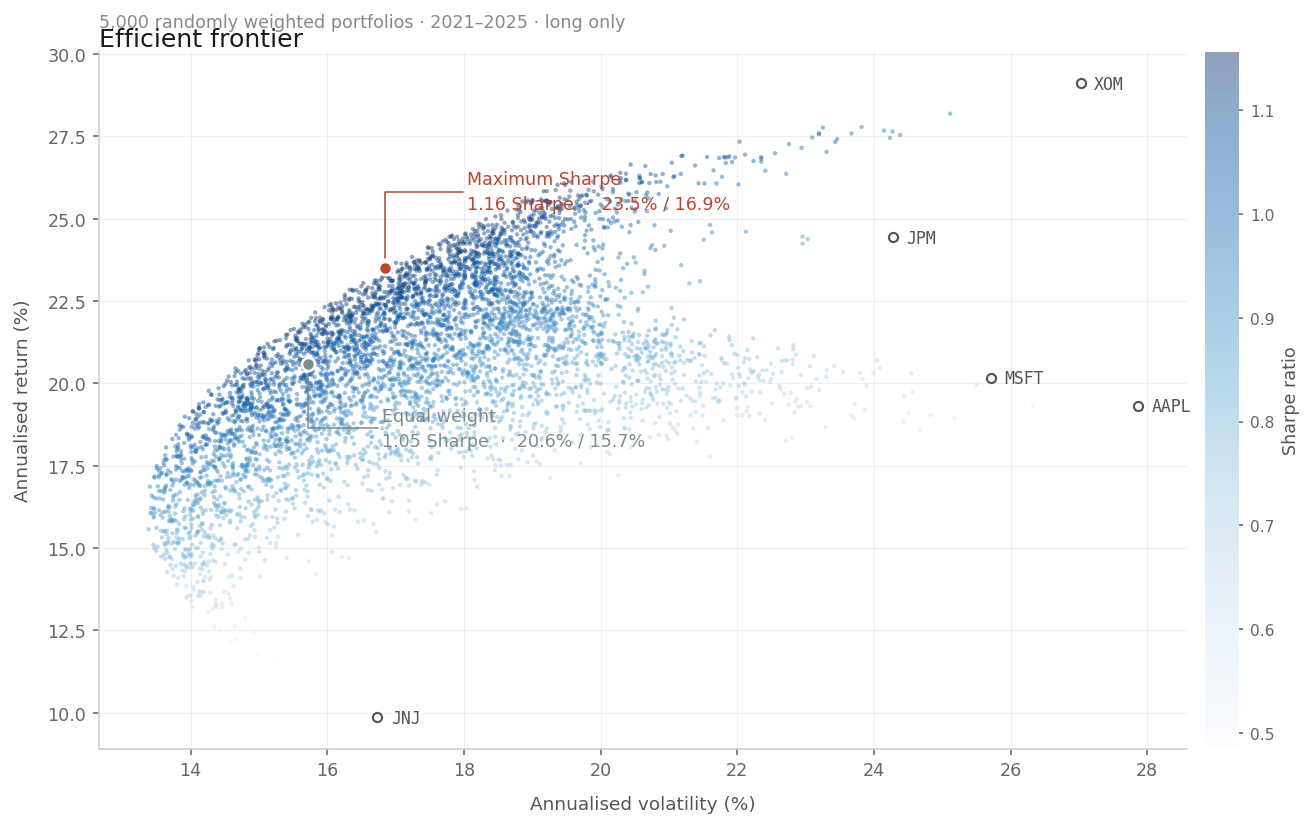

In [10]:
import matplotlib.pyplot as plt

w = np.random.dirichlet(np.ones(5), 5000)
rets = w @ annual_return
vols = np.sqrt(np.einsum("ij,jk,ik->i", w, cov, w))
opt_vol = (result.x @ cov @ result.x) ** 0.5
opt_ret = annual_return @ result.x
opt_sr = (opt_ret - rf) / opt_vol
eq_sr = (port_return - rf) / port_vol

fig, ax = plt.subplots(figsize=(9.5, 6), dpi=140)
fig.patch.set_facecolor("white")

sc = ax.scatter(vols * 100, rets * 100, c=(rets - rf) / vols,
                s=5, cmap="Blues", alpha=0.45, linewidths=0, zorder=1)

ax.scatter(annual_vol * 100, annual_return * 100, s=22, facecolor="white",
           edgecolor="#555", linewidth=1.1, zorder=4)
for n, v, r in zip(names, annual_vol, annual_return):
    ax.annotate(n, (v * 100, r * 100), xytext=(7, -3), textcoords="offset points",
                fontsize=8.5, color="#555", family="monospace")

for x, y, lab, val, col, dx, dy in [
    (port_vol, port_return, "Equal weight", eq_sr, "#7f8c8d", 38, -42),
    (opt_vol, opt_ret, "Maximum Sharpe", opt_sr, "#b8462f", 42, 30)]:
    ax.scatter(x * 100, y * 100, s=46, facecolor=col, edgecolor="white",
               linewidth=1.4, zorder=6)
    ax.annotate(f"{lab}\n{val:.2f} Sharpe  ·  {y*100:.1f}% / {x*100:.1f}%",
                (x * 100, y * 100), xytext=(dx, dy), textcoords="offset points",
                fontsize=9, color=col, linespacing=1.5, zorder=7,
                arrowprops=dict(arrowstyle="-", color=col, linewidth=0.8,
                                shrinkA=0, shrinkB=5,
                                connectionstyle="angle,angleA=0,angleB=90,rad=0"))

ax.set_title("Efficient frontier", fontsize=13, loc="left", pad=2, color="#1a1a1a")
ax.text(0, 1.035, "5,000 randomly weighted portfolios · 2021–2025 · long only",
        transform=ax.transAxes, fontsize=9, color="#888")
ax.set_xlabel("Annualised volatility (%)", fontsize=9.5, color="#555", labelpad=8)
ax.set_ylabel("Annualised return (%)", fontsize=9.5, color="#555", labelpad=8)
ax.tick_params(labelsize=9, colors="#666", length=3)
ax.grid(alpha=0.18, linewidth=0.6)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color("#ccc")
    ax.spines[s].set_linewidth(0.8)

cb = fig.colorbar(sc, ax=ax, pad=0.015, fraction=0.035)
cb.set_label("Sharpe ratio", fontsize=9, color="#555")
cb.ax.tick_params(labelsize=8, colors="#666", length=2)
cb.outline.set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
train = returns.loc[:"2023-12-31"]
test = returns.loc["2024-01-01":]

train_ret = train.mean() * 252
train_cov = train.cov() * 252

print(len(train), "training days |", len(test), "testing days")

752 training days | 502 testing days


In [12]:
def neg_sharpe_train(w):
    return -(train_ret @ w - rf) / (w @ train_cov @ w) ** 0.5

res_train = minimize(neg_sharpe_train, np.array([0.2] * 5),
                     bounds=[(0, 1)] * 5,
                     constraints={"type": "eq", "fun": lambda w: w.sum() - 1})

w_opt = res_train.x
print(dict(zip(names, w_opt.round(3))))

{'AAPL': np.float64(0.0), 'JNJ': np.float64(0.0), 'JPM': np.float64(0.0), 'MSFT': np.float64(0.368), 'XOM': np.float64(0.632)}


In [13]:
w_eq = np.array([0.2] * 5)

def stats(w, r):
    p = r @ w
    ann_r, ann_v = p.mean() * 252, p.std() * (252 ** 0.5)
    return ann_r, ann_v, (ann_r - rf) / ann_v

for label, w in [("Optimised", w_opt), ("Equal weight", w_eq)]:
    r, v, s = stats(w, test)
    print(f"{label:<14} return {r*100:5.1f}%   vol {v*100:5.1f}%   Sharpe {s:.2f}")

Optimised      return  15.4%   vol  16.2%   Sharpe 0.70
Equal weight   return  21.7%   vol  13.9%   Sharpe 1.27


In [14]:
for label, w in [("Optimised", w_opt), ("Equal weight", w_eq)]:
    curve = (1 + test @ w).cumprod()
    dd = (curve / curve.cummax() - 1).min()
    print(f"{label:<14} max drawdown {dd*100:.1f}%")

Optimised      max drawdown -16.1%
Equal weight   max drawdown -16.0%


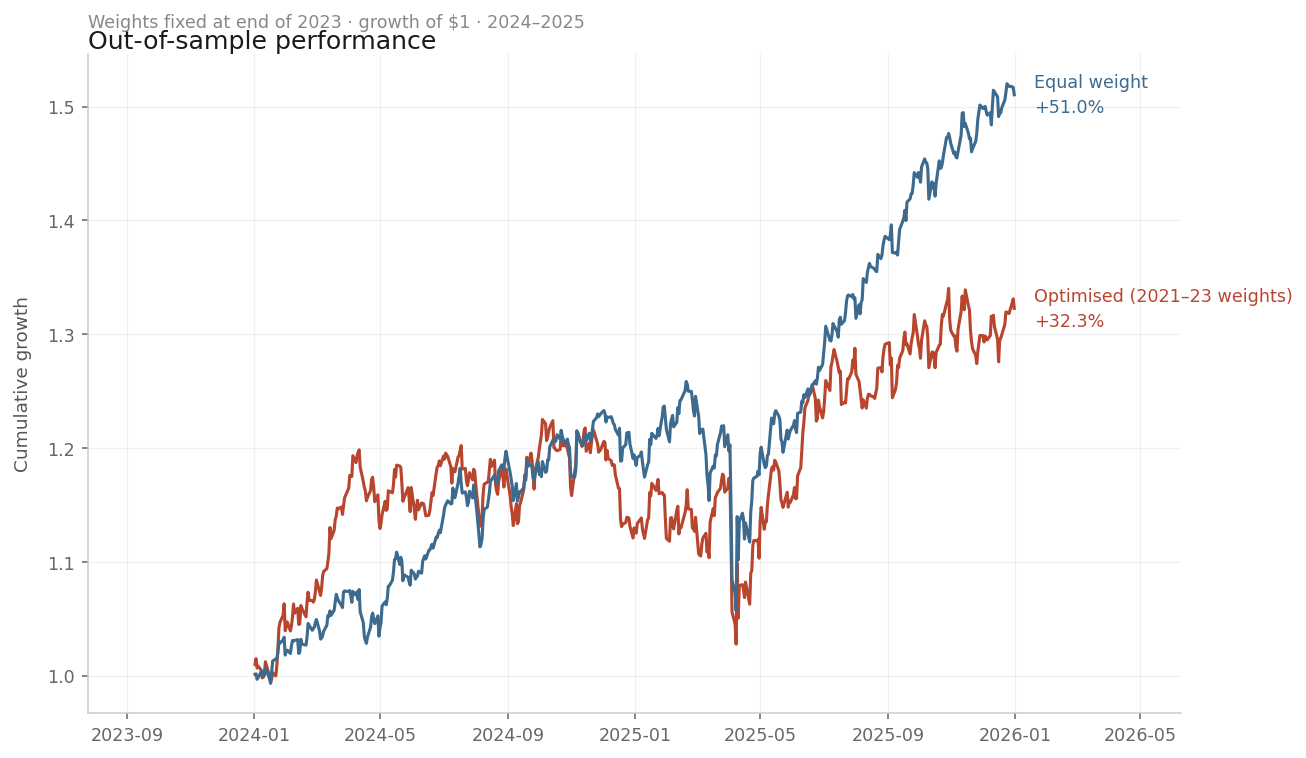

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.5), dpi=140)
for label, w, col in [("Optimised (2021–23 weights)", w_opt, "#b8462f"),
                      ("Equal weight", w_eq, "#3d6b8f")]:
    curve = (1 + test @ w).cumprod()
    ax.plot(curve.index, curve.values, color=col, linewidth=1.6, label=label)
    ax.annotate(f"{label}\n{(curve.iloc[-1]-1)*100:+.1f}%", (curve.index[-1], curve.iloc[-1]),
                xytext=(10, 0), textcoords="offset points", fontsize=9,
                color=col, va="center", linespacing=1.5)

ax.set_title("Out-of-sample performance", fontsize=13, loc="left", pad=2, color="#1a1a1a")
ax.text(0, 1.04, "Weights fixed at end of 2023 · growth of $1 · 2024–2025",
        transform=ax.transAxes, fontsize=9, color="#888")
ax.set_ylabel("Cumulative growth", fontsize=9.5, color="#555", labelpad=8)
ax.tick_params(labelsize=9, colors="#666", length=3)
ax.grid(alpha=0.18, linewidth=0.6); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color("#ccc"); ax.spines[s].set_linewidth(0.8)
ax.margins(x=0.22)
plt.tight_layout(); plt.show()